# Secondary Market Supply Shocks — Event Study Visualization
## Scarcity Premium Erosion After Official Re-release (Mercari Japan, Assets A–F)

This notebook visualises the event-study output produced by `03_analysis.py`.  
All price series are **baseline-mean indexed**: `normalized_price = 1.0` represents
the average pre-T2 secondary market price for each asset
(day-equally-weighted mean of daily medians across all pre-T2 days).

| Symbol | Meaning |
|--------|---------|
| **τ** | Calendar days relative to T2 (T2 = Day 0) |
| **T1** | Official re-release **announcement** date |
| **T2** | Official re-release date (new stock physically available) |
| **Phase 1** | τ ∈ \[T1−90, T1): pure scarcity baseline, no announcement |
| **Phase 2** | τ ∈ \[T1, 0): announce-to-release window, expectation effects |
| **Phase 3** | τ ∈ \[0, max_post\]: post-release supply shock period |

**Data**: `data_clean/analysis_output.csv` — 180 daily rows × 6 assets (439 raw transactions post-02b)

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from matplotlib.ticker import MultipleLocator
from IPython.display import display
from pathlib import Path

# ── Paths ──────────────────────────────────────────────────────────────────
BASE = Path("..") if (Path("..") / "data_clean").exists() else Path(".")
CSV  = BASE / "data_clean" / "analysis_output.csv"
FIG  = BASE / "report" / "figures"
FIG.mkdir(parents=True, exist_ok=True)

# ── Matplotlib defaults (academic white style) ──────────────────────────────
plt.rcParams.update({
    "figure.dpi":        130,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.titlesize":    9,
    "axes.labelsize":    8,
    "xtick.labelsize":   7,
    "ytick.labelsize":   7,
    "legend.fontsize":   8,
})

# ── Asset metadata ──────────────────────────────────────────────────────────
ASSET_ORDER = [
    "asset_a_action_figure",
    "asset_b_acrylic_stand",
    "asset_c_plush_mascot",
    "asset_d_holographic_badge",
    "asset_e_classic_badge",
    "asset_f_lottery_plush",
]
ASSET_LABELS = {
    "asset_a_action_figure":     "Asset A — Action Figure",
    "asset_b_acrylic_stand":     "Asset B — Acrylic Stand",
    "asset_c_plush_mascot":      "Asset C — Plush Mascot",
    "asset_d_holographic_badge": "Asset D — Holographic Badge",
    "asset_e_classic_badge":     "Asset E — Classic Badge",
    "asset_f_lottery_plush":     "Asset F — Lottery Plush",
}
ASSET_COLORS = {
    "asset_a_action_figure":     "#1f77b4",  # blue
    "asset_b_acrylic_stand":     "#ff7f0e",  # orange
    "asset_c_plush_mascot":      "#2ca02c",  # green
    "asset_d_holographic_badge": "#d62728",  # red
    "asset_e_classic_badge":     "#9467bd",  # purple
    "asset_f_lottery_plush":     "#8c564b",  # brown
}
# Assets where the post-release observation window is short / results low-confidence
RIGHT_TRUNCATED = {"asset_b_acrylic_stand", "asset_f_lottery_plush"}

print("Setup complete.")
print("Figures will be saved to:", FIG.resolve())

Setup complete.
Figures will be saved to: /Users/hxl/cursor_docs/secondary-market-supply-shocks/report/figures


In [3]:
# ── Load analysis output ────────────────────────────────────────────────────
df = pd.read_csv(CSV)
df["date"] = pd.to_datetime(df["date"])

print(f"Rows loaded : {len(df)}  ({df['asset_id'].nunique()} assets)")
print(f"tau range   : [{df['tau'].min()}, {df['tau'].max()}]")
print()

overview = (
    df.groupby("asset_id")
    .agg(
        Asset=("asset_en_name", "first"),
        tau_min=("tau", "min"),
        tau_max=("tau", "max"),
        pre_days=("tau",  lambda s: (s < 0).sum()),
        post_days=("tau", lambda s: (s >= 0).sum()),
        pre_raw_obs=("n_pre_rows", "first"),
        baseline_yen=("baseline_mean", "first"),
    )
    .reset_index(drop=True)
    .set_index("Asset")
)
overview.columns = ["tau min", "tau max", "Pre Days", "Post Days",
                    "Pre Raw Obs.", "Baseline (¥)"]
display(
    overview
    .style
    .format({"Baseline (¥)": "¥{:,.0f}"})
    .set_caption("Per-Asset Data Coverage")
)

Rows loaded : 180  (6 assets)
tau range   : [-287, 137]



,tau min,tau max,Pre Days,Post Days,Pre Raw Obs.,Baseline (¥)
Asset,,,,,,
Asset A: Action Figure,-127,113,5,7,5,"¥7,365"
Asset B: Acrylic Stand,-154,34,11,1,12,"¥2,074"
Asset C: Plush Mascot,-45,118,8,68,10,"¥7,886"
Asset D: Holographic Badge,-135,118,21,17,25,¥498
Asset E: Classic Badge,-94,137,6,16,6,"¥2,644"
Asset F: Lottery Plush,-287,24,15,5,19,"¥9,800"


## Part 1: Summary Statistics

**Table 1** shows the baseline period used to normalise each asset's price series.  
**Table 2** shows the supply shock magnitude: how much the scarcity premium eroded after T2.

> **Methodology note** (§3.3 of the research report): The baseline mean is the
> day-equally-weighted mean of daily medians over all τ < 0 days within the
> observation window. For all assets except C, this baseline period includes both
> Phase 1 (pre-announcement) and Phase 2 (announce-to-release), so the measured
> erosion understates the true supply shock relative to a pure Phase-1 baseline.
> Asset C (T1 = T2) is the exception: its entire pre-T2 period is Phase 1,
> making it the cleanest scarcity-premium reference in this dataset.

In [4]:
# ── Table 1: Baseline Statistics ───────────────────────────────────────────
t1 = (
    df.groupby("asset_id")
    .agg(
        Asset=("asset_en_name", "first"),
        n_pre_rows=("n_pre_rows", "first"),
        n_pre_days=("n_pre_days", "first"),
        baseline_mean=("baseline_mean", "first"),
    )
    .reset_index(drop=True)
    .set_index("Asset")
)
t1.columns = ["Pre-T2 Obs.", "Pre-T2 Days", "Baseline Mean (¥)"]
print("Table 1 — Per-Asset Baseline Statistics")
display(
    t1.style
    .format({"Baseline Mean (¥)": "¥{:,.0f}"})
    .set_caption(
        "Baseline = day-equally-weighted mean of daily medians for τ < 0. "
        "Asset C is the cleanest baseline (T1=T2, entire pre-T2 is Phase 1)."
    )
)

print()

# ── Table 2: Supply Shock Magnitude ────────────────────────────────────────
rows = []
for aid in ASSET_ORDER:
    g    = df[df["asset_id"] == aid]
    post = g[g["tau"] >= 0]
    bm   = g["baseline_mean"].iloc[0]
    pm   = post["normalized_price"].median() if len(post) > 0 else np.nan
    erosion = (1 - pm) * 100 if not np.isnan(pm) else np.nan
    note = ""
    if aid in RIGHT_TRUNCATED:
        note = "right-truncated window"
    if not np.isnan(pm) and pm > 1.0:
        note += (" | " if note else "") + "post > pre (anomaly, low n)"
    rows.append({
        "Asset":            ASSET_LABELS[aid],
        "Post Days":        len(post),
        "Post Med. (norm.)": pm,
        "Erosion (%)": erosion,
        "Baseline (¥)":     bm,
        "Note":             note,
    })

t2 = pd.DataFrame(rows).set_index("Asset")
print("Table 2 — Scarcity Premium Erosion After Official Re-release")
display(
    t2.style
    .format({
        "Post Med. (norm.)": "{:.3f}",
        "Erosion (%)": "{:.1f}%",
        "Baseline (¥)": "¥{:,.0f}",
    })
    .bar(subset=["Erosion (%)"], color="#d9f0d3", vmin=0, vmax=50)
    .set_caption(
        "Erosion = 1 − (post median normalized price). "
        "Asset C provides the cleanest signal; B and F have short post-windows."
    )
)

Table 1 — Per-Asset Baseline Statistics


,Pre-T2 Obs.,Pre-T2 Days,Baseline Mean (¥)
Asset,,,
Asset A: Action Figure,5,5,"¥7,365"
Asset B: Acrylic Stand,12,11,"¥2,074"
Asset C: Plush Mascot,10,8,"¥7,886"
Asset D: Holographic Badge,25,21,¥498
Asset E: Classic Badge,6,6,"¥2,644"
Asset F: Lottery Plush,19,15,"¥9,800"



Table 2 — Scarcity Premium Erosion After Official Re-release


,Post Days,Post Med. (norm.),Erosion (%),Baseline (¥),Note
Asset,,,,,
Asset A — Action Figure,7,0.720,28.0%,"¥7,365",
Asset B — Acrylic Stand,1,0.674,32.6%,"¥2,074",right-truncated window
Asset C — Plush Mascot,68,0.579,42.1%,"¥7,886",
Asset D — Holographic Badge,17,0.831,16.9%,¥498,
Asset E — Classic Badge,16,0.916,8.4%,"¥2,644",
Asset F — Lottery Plush,5,0.918,8.2%,"¥9,800",right-truncated window


## Part 2: Individual Asset Trajectories (Figure 1)

Each panel shows the **normalized daily median price** for one asset over the event window.

> **Background shading — Phase color coding:**
> - 🔵 **Blue = Phase 1** — Pre-announcement scarcity baseline period (τ ∈ \[T1−90, T1))
> - 🟠 **Orange = Phase 2** — Announce-to-release expectation window (τ ∈ \[T1, 0))
> - 🟢 **Green = Phase 3** — Post-release supply shock period (τ ∈ \[0, max_post\])
>
> Note: Asset C has T1 = T2 (Day 0), so **Phase 2 is empty** and the entire pre-T2 period is Phase 1 (cleanest baseline).

- **Scatter points**: each dot = one trading day's median (filled ● = reliable, n ≥ 3 transactions; hollow ○ = sparse, n < 3)
- **Smoothed line**: 7-point rolling median over adjacent observed trading days  
  *(smooths over data points, not calendar days — sparse assets show little additional smoothing)*
- **Vertical lines**: T1 dotted line (announcement date) and T2 solid line (release, Day 0)
- **Dashed horizontal**: y = 1.0 baseline reference
- **[!] right-truncated**: Asset B (post window ≤ +50 d, 1 post obs.) and Asset F (≤ +71 d, 6 post obs.) — conclusions limited to truncated window

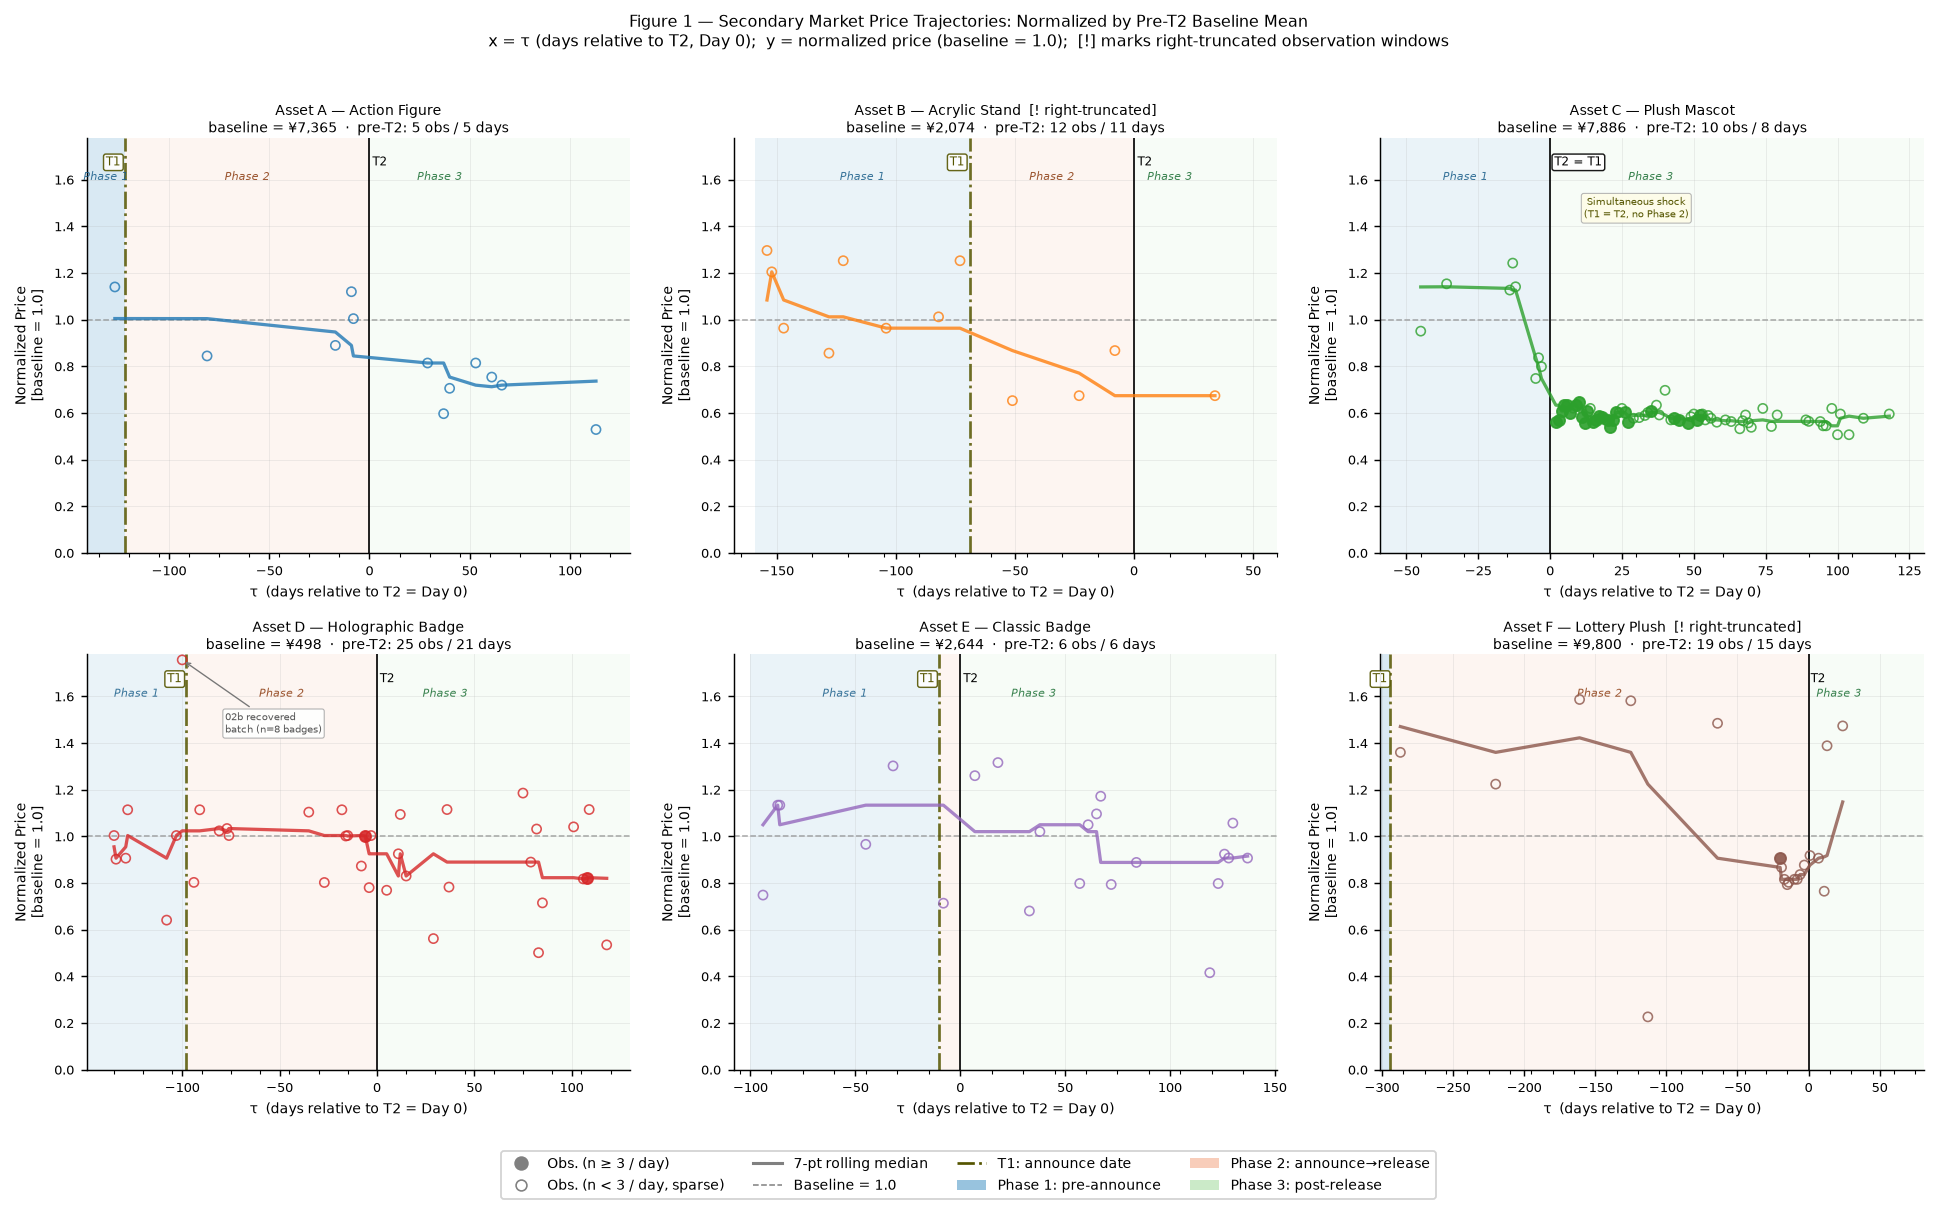

Saved → ../report/figures/fig_01_all_assets_grid.png


In [5]:
Y_LO, Y_HI = 0.0, 1.78  # shared y-axis limits across all panels

def plot_asset(ax, asset_id):
    """Draw normalized price trajectory for one asset on the given Axes."""
    color    = ASSET_COLORS[asset_id]
    d        = df[df["asset_id"] == asset_id].sort_values("tau").copy()
    tau_T1   = int(d["tau_T1"].iloc[0])
    max_post = int(d["max_post_day"].iloc[0])
    bm       = d["baseline_mean"].iloc[0]
    n_pre    = int(d["n_pre_rows"].iloc[0])
    n_pre_d  = int(d["n_pre_days"].iloc[0])
    x_lo     = d["tau"].min() - 14
    x_hi     = max_post + 10

    # ── Phase background shading + text labels ───────────────────────────
    # Phase 1: [tau_T1-90, tau_T1)  — capped at x_lo on the left
    ph1_lo = max(x_lo, tau_T1 - 90)
    ph1_hi = tau_T1  # (= 0 for Asset C, so Phase 2 block below is skipped)
    if ph1_lo < ph1_hi:
        # Narrow Phase 1 strip (e.g. Asset A ≈19 days): boost alpha for visibility
        ph1_alpha = 0.20 if ph1_hi - ph1_lo < 25 else 0.11
        ax.axvspan(ph1_lo, ph1_hi, alpha=ph1_alpha, color="#4393c3", zorder=0, lw=0)
        if ph1_hi - ph1_lo > 10:   # lowered from 20 → Asset A's 19-day strip now labelled
            ax.text((ph1_lo + ph1_hi) / 2, Y_HI * 0.92,
                    "Phase 1", fontsize=6, ha="center", va="top",
                    color="#1a5e8a", alpha=0.85, fontstyle="italic")
    # Phase 2: [tau_T1, 0)  — only exists when T1 precedes T2
    if tau_T1 < 0:
        ax.axvspan(tau_T1, 0, alpha=0.11, color="#f4a582", zorder=0, lw=0)
        if abs(tau_T1) > 20:  # only label if Phase 2 is wide enough
            ax.text(tau_T1 / 2, Y_HI * 0.92,
                    "Phase 2", fontsize=6, ha="center", va="top",
                    color="#8b3a0f", alpha=0.85, fontstyle="italic")
    # Phase 3: [0, max_post]
    ax.axvspan(0, x_hi, alpha=0.08, color="#a1d99b", zorder=0, lw=0)
    ph3_label_x = min(max_post * 0.30, 35)  # label at 30% into Phase 3
    ax.text(ph3_label_x, Y_HI * 0.92,
            "Phase 3", fontsize=6, ha="center", va="top",
            color="#1a6e33", alpha=0.85, fontstyle="italic")

    # ── Reference lines ──────────────────────────────────────────────────
    ax.set_ylim(Y_LO, Y_HI)            # set early so text positions are correct
    ax.axhline(1.0, color="gray", linestyle="--", linewidth=0.85, alpha=0.7, zorder=1)
    ax.axvline(0, color="black", linewidth=1.1, alpha=0.85, zorder=2)
    # T2 label — special combined label for Asset C where T1 = T2
    if tau_T1 == 0:
        ax.text(1.5, Y_HI - 0.08, "T2 = T1", fontsize=6.5, color="black", va="top",
                bbox=dict(boxstyle="round,pad=0.2", facecolor="white",
                          edgecolor="black", alpha=0.9, linewidth=0.8))
        ax.text(30, Y_HI * 0.86, "Simultaneous shock\n(T1 = T2, no Phase 2)",
                fontsize=5.5, color="#555500", va="top", ha="center",
                bbox=dict(boxstyle="round,pad=0.25", facecolor="#fffde7",
                          edgecolor="#aaaaaa", alpha=0.85, linewidth=0.6))
    else:
        ax.text(1.5, Y_HI - 0.08, "T2", fontsize=6.5, color="black", va="top")
    # T1 line — thicker (1.5 pt), dash-dot, dark olive #555500, bbox label
    if tau_T1 != 0:
        ax.axvline(tau_T1, color="#555500", linewidth=1.5, linestyle="-.",
                   alpha=0.85, zorder=2)
        ax.text(tau_T1 - 2, Y_HI - 0.08, "T1", fontsize=6.5,
                color="#555500", va="top", ha="right",
                bbox=dict(boxstyle="round,pad=0.2", facecolor="white",
                          edgecolor="#555500", alpha=0.9, linewidth=0.8))

    # ── Scatter points ───────────────────────────────────────────────────
    rel   = d[d["reliable_day"] == True]
    unrel = d[d["reliable_day"] == False]
    # Hollow markers for sparse days (n < 3)
    ax.scatter(unrel["tau"], unrel["normalized_price"],
               s=26, facecolors="none", edgecolors=color,
               linewidths=0.9, alpha=0.8, zorder=4)
    # Filled markers for reliable days (n >= 3)
    if len(rel):
        ax.scatter(rel["tau"], rel["normalized_price"],
                   s=38, color=color, alpha=0.9, zorder=5)

    # ── 7-point rolling median (smoothed line) ───────────────────────────
    if len(d) >= 2:
        d["roll"] = (
            d["normalized_price"]
            .rolling(window=7, min_periods=1, center=True)
            .median()
        )
        ax.plot(d["tau"], d["roll"],
                color=color, linewidth=1.8, alpha=0.8, zorder=3)

    # ── Special annotation: Asset D batch purchase (02b recovered, τ=−100) ─
    if asset_id == "asset_d_holographic_badge":
        batch = d[(d["tau"] == -100) & (d["normalized_price"] > 1.5)]
        if len(batch):
            bp_tau  = int(batch["tau"].iloc[0])
            bp_norm = float(batch["normalized_price"].iloc[0])
            ax.annotate(
                "02b recovered\nbatch (n=8 badges)",
                xy=(bp_tau, bp_norm),
                xytext=(bp_tau + 22, bp_norm - 0.22),
                fontsize=5.5, color="#555555", ha="left", va="top",
                arrowprops=dict(arrowstyle="->", color="#777777", lw=0.75),
                bbox=dict(boxstyle="round,pad=0.22", facecolor="white",
                          edgecolor="#aaaaaa", alpha=0.92, linewidth=0.6),
                zorder=6
            )

    # ── Axes formatting ──────────────────────────────────────────────────
    ax.set_xlim(x_lo, x_hi)
    ax.set_ylim(Y_LO, Y_HI)
    ax.set_xlabel("τ  (days relative to T2 = Day 0)", fontsize=7.5)
    ax.set_ylabel("Normalized Price\n[baseline = 1.0]", fontsize=7.5)
    ax.grid(True, alpha=0.22, linewidth=0.5)
    ax.xaxis.set_minor_locator(MultipleLocator(15))

    trunc_note = "  [! right-truncated]" if asset_id in RIGHT_TRUNCATED else ""
    ax.set_title(
        f"{ASSET_LABELS[asset_id]}{trunc_note}\n"
        f"baseline = ¥{bm:,.0f}  ·  pre-T2: {n_pre} obs / {n_pre_d} days",
        fontsize=8, pad=3
    )


# ── 2 × 3 panel grid ────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for ax, asset_id in zip(axes.flatten(), ASSET_ORDER):
    plot_asset(ax, asset_id)

# Shared legend below the grid
legend_handles = [
    Line2D([0],[0], marker="o", color="none", markerfacecolor="gray",
           markeredgecolor="gray", markersize=7, label="Obs. (n ≥ 3 / day)"),
    Line2D([0],[0], marker="o", color="none", markerfacecolor="none",
           markeredgecolor="gray", markeredgewidth=0.9,
           markersize=6, label="Obs. (n < 3 / day, sparse)"),
    Line2D([0],[0], color="gray", linewidth=1.7, label="7-pt rolling median"),
    Line2D([0],[0], color="gray", linestyle="--", linewidth=0.85, label="Baseline = 1.0"),
    Line2D([0],[0], color="#555500", linewidth=1.5, linestyle="-.", label="T1: announce date"),
    mpatches.Patch(facecolor="#4393c3", alpha=0.55, label="Phase 1: pre-announce"),
    mpatches.Patch(facecolor="#f4a582", alpha=0.55, label="Phase 2: announce→release"),
    mpatches.Patch(facecolor="#a1d99b", alpha=0.55, label="Phase 3: post-release"),
]
fig.legend(
    handles=legend_handles, loc="lower center", ncol=4, fontsize=8,
    bbox_to_anchor=(0.5, -0.01), framealpha=0.85,
)
fig.suptitle(
    "Figure 1 — Secondary Market Price Trajectories: Normalized by Pre-T2 Baseline Mean\n"
    "x = τ (days relative to T2, Day 0);  y = normalized price (baseline = 1.0);  "
    "[!] marks right-truncated observation windows",
    fontsize=9, y=1.01
)
plt.tight_layout(rect=[0, 0.05, 1, 1])

out1 = FIG / "fig_01_all_assets_grid.png"
fig.savefig(out1, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {out1}")

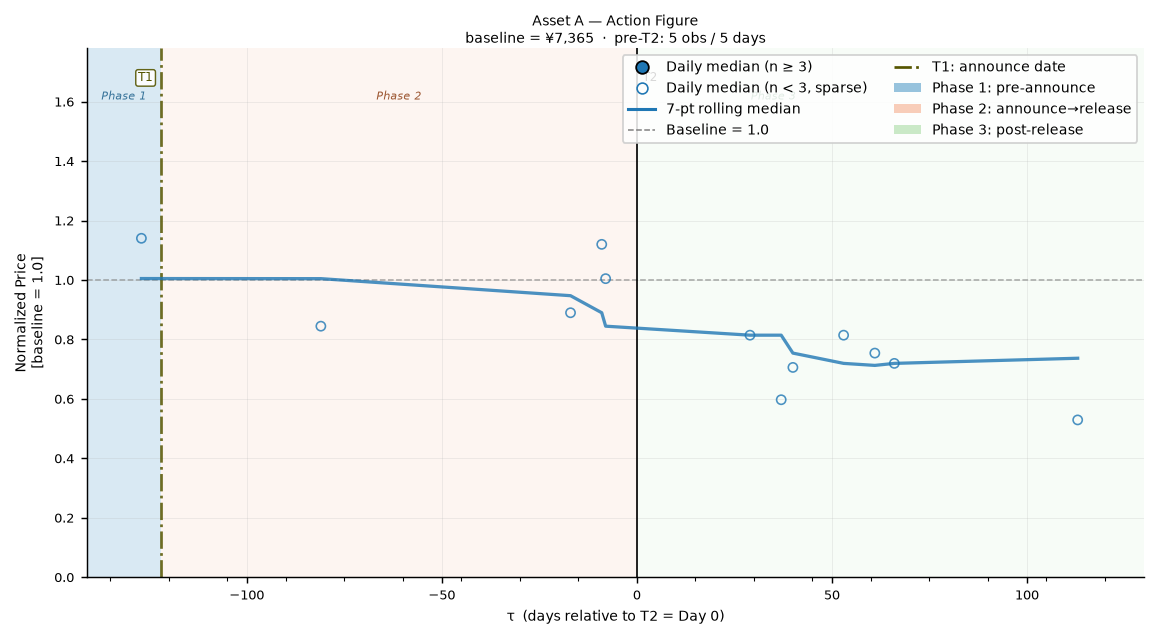

Saved → ../report/figures/fig_asset_a.png


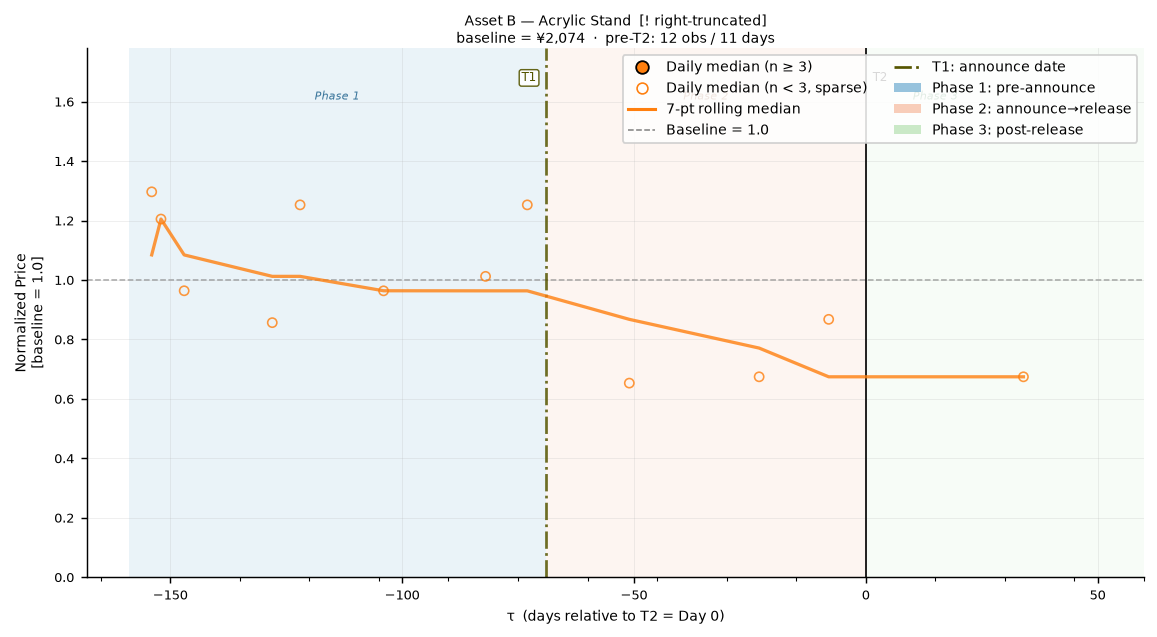

Saved → ../report/figures/fig_asset_b.png


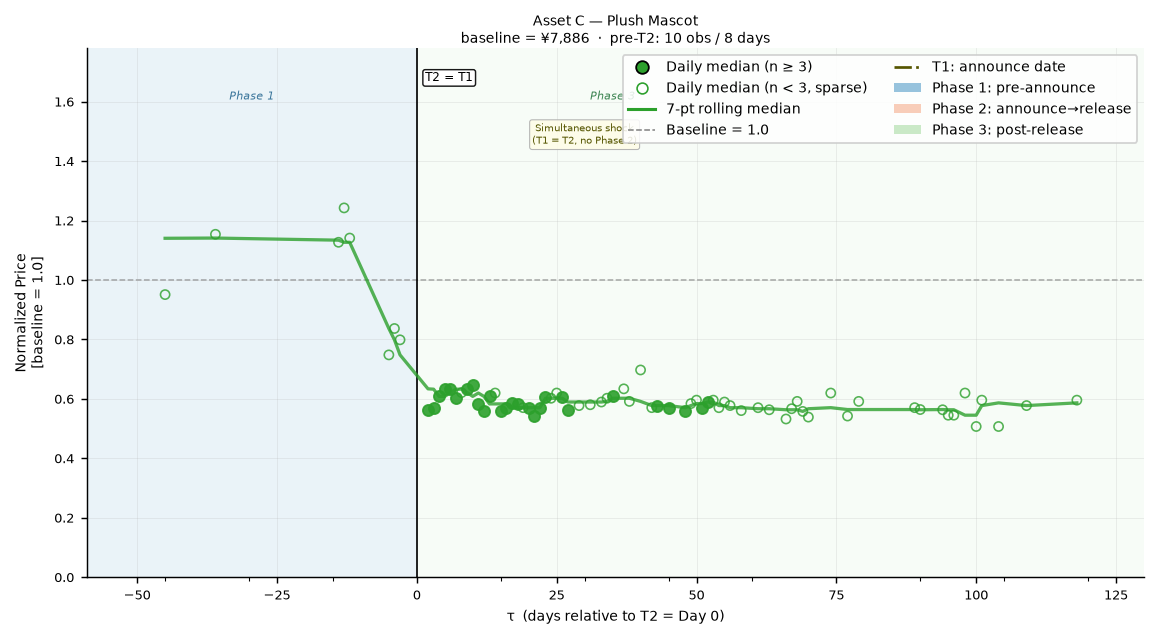

Saved → ../report/figures/fig_asset_c.png


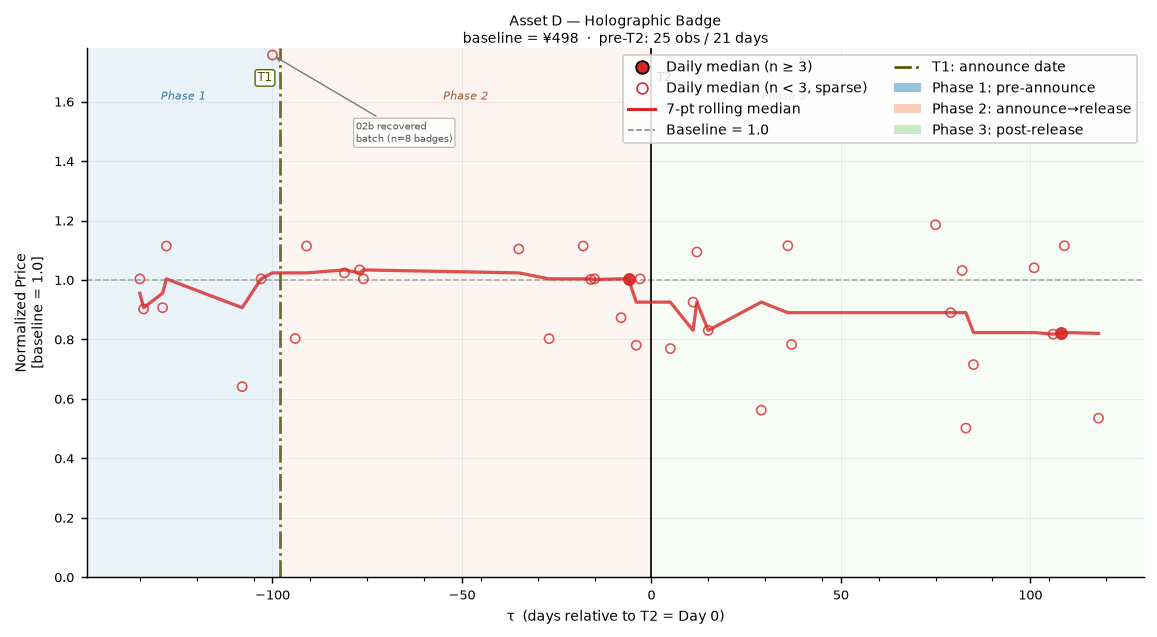

Saved → ../report/figures/fig_asset_d.png


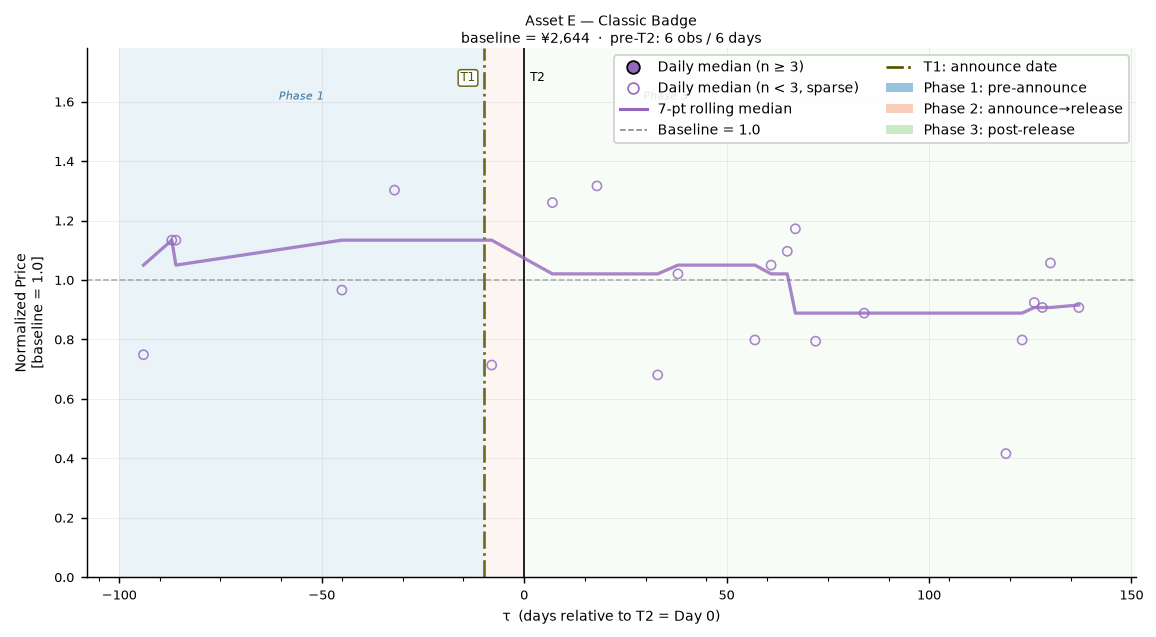

Saved → ../report/figures/fig_asset_e.png


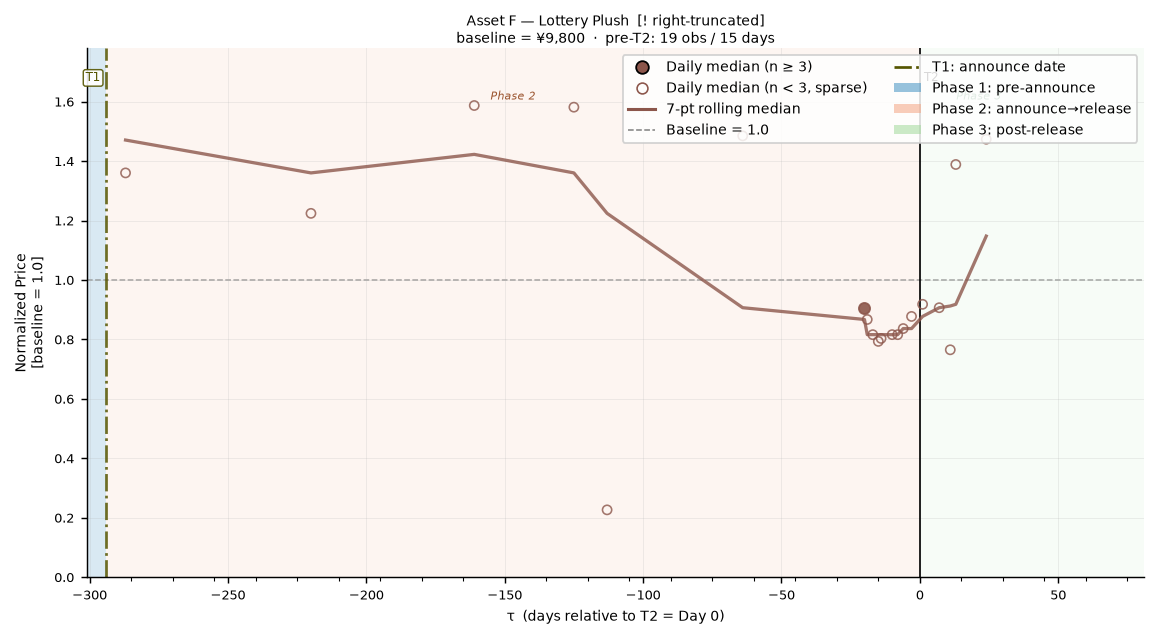

Saved → ../report/figures/fig_asset_f.png


In [6]:
# ── Individual high-resolution figures (one per asset) ──────────────────────
# These are suitable for direct insertion into the research report.

for asset_id in ASSET_ORDER:
    fig_i, ax_i = plt.subplots(figsize=(9, 5))
    plot_asset(ax_i, asset_id)

    # Add legend inside the individual figure
    leg_handles = [
        Line2D([0],[0], marker="o", color="none",
               markerfacecolor=ASSET_COLORS[asset_id],
               markersize=7, label="Daily median (n ≥ 3)"),
        Line2D([0],[0], marker="o", color="none",
               markerfacecolor="none",
               markeredgecolor=ASSET_COLORS[asset_id],
               markeredgewidth=0.9, markersize=6, label="Daily median (n < 3, sparse)"),
        Line2D([0],[0], color=ASSET_COLORS[asset_id], linewidth=1.7,
               label="7-pt rolling median"),
        Line2D([0],[0], color="gray", linestyle="--", linewidth=0.85, label="Baseline = 1.0"),
        Line2D([0],[0], color="#555500", linewidth=1.5, linestyle="-.", label="T1: announce date"),
        mpatches.Patch(facecolor="#4393c3", alpha=0.55, label="Phase 1: pre-announce"),
        mpatches.Patch(facecolor="#f4a582", alpha=0.55, label="Phase 2: announce→release"),
        mpatches.Patch(facecolor="#a1d99b", alpha=0.55, label="Phase 3: post-release"),
    ]
    ax_i.legend(handles=leg_handles, fontsize=7.5, loc="upper right",
                framealpha=0.85, ncol=2)
    plt.tight_layout()

    short = asset_id.split("_")[1]  # e.g. 'a', 'b', ...
    out_i = FIG / f"fig_asset_{short}.png"
    fig_i.savefig(out_i, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved → {out_i}")

## Part 3: Cross-Asset Comparison (Figure 2)

All six assets are overlaid on a single panel, aligned at T2 (Day 0).
Only the **7-point rolling median line** is shown per asset (no scatter) to keep the chart readable.

- **Solid lines**: Assets A, C, D, E — full observation windows
- **Dashed lines**: Assets B, F — right-truncated windows (low post-T2 sample)
- **Asset F** anomaly (post > pre) is clearly visible in the green-brown line rising above 1.0; post n = 6 raw rows, not statistically robust
- **Asset C** (green, cleanest baseline) shows the largest drop: −42% below baseline

> Note: Asset F's pre-T2 data extends to τ = −287; the left x-axis is truncated at −175 for readability.

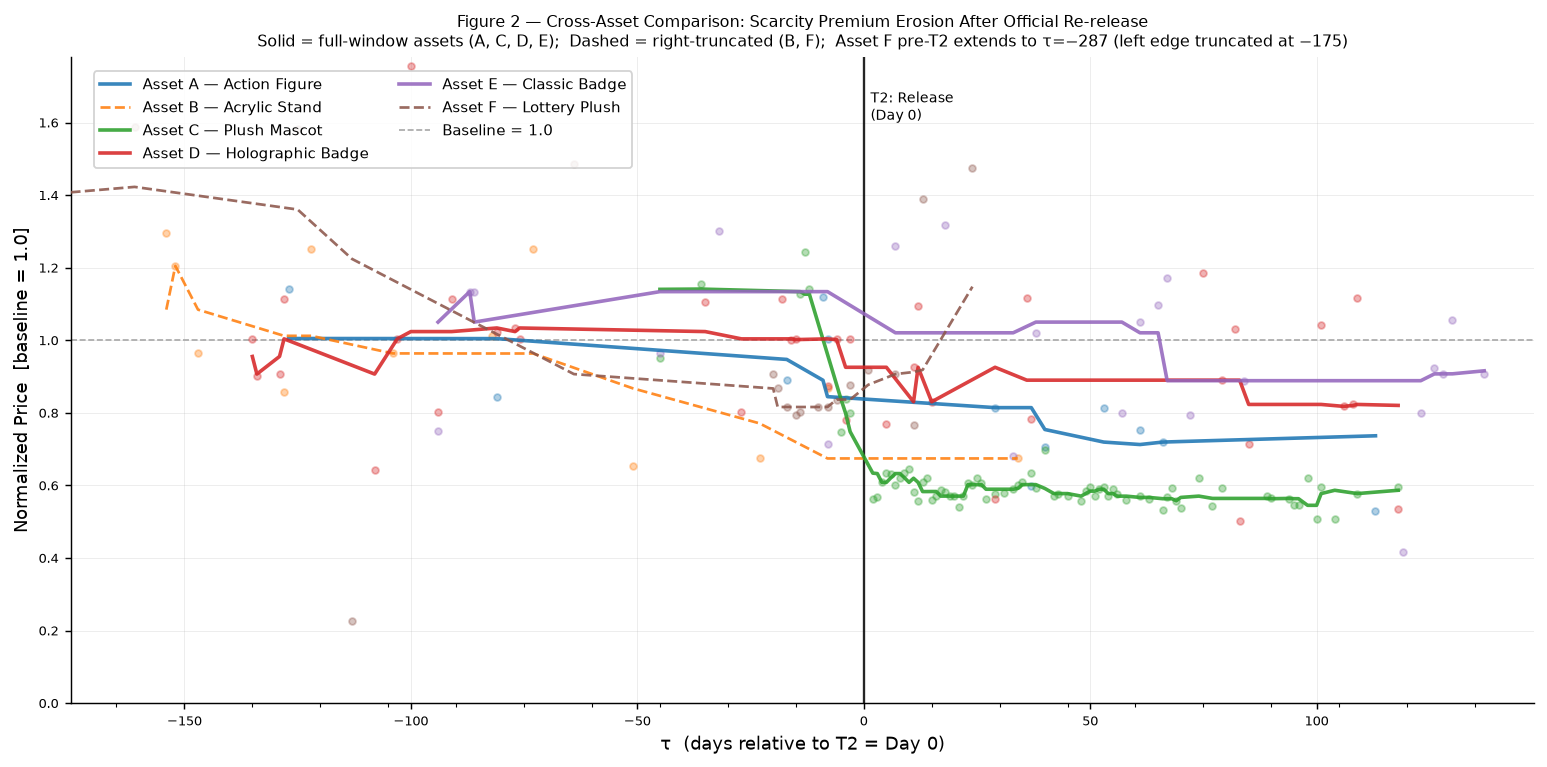

Saved → ../report/figures/fig_02_combined_overlay.png


In [7]:
fig2, ax2 = plt.subplots(figsize=(12, 6))

for asset_id in ASSET_ORDER:
    d     = df[df["asset_id"] == asset_id].sort_values("tau").copy()
    color = ASSET_COLORS[asset_id]
    label = ASSET_LABELS[asset_id]
    lw    = 2.0 if asset_id not in RIGHT_TRUNCATED else 1.5
    ls    = "-"  if asset_id not in RIGHT_TRUNCATED else "--"

    # Small scatter dots (underlying data)
    ax2.scatter(d["tau"], d["normalized_price"],
                s=14, color=color, alpha=0.35, zorder=3)

    # 7-point rolling median line
    d["roll"] = (
        d["normalized_price"]
        .rolling(window=7, min_periods=1, center=True)
        .median()
    )
    ax2.plot(d["tau"], d["roll"],
             color=color, linewidth=lw, linestyle=ls,
             label=label, alpha=0.88, zorder=4)

# Reference lines
ax2.axhline(1.0, color="dimgray", linestyle="--", linewidth=0.9,
            alpha=0.6, zorder=1, label="Baseline = 1.0")
ax2.axvline(0, color="black", linewidth=1.3, alpha=0.85, zorder=2)
ax2.text(1.5, 1.69, "T2: Release\n(Day 0)", fontsize=8,
         color="black", va="top")

# Axes
ax2.set_xlim(-175, 148)
ax2.set_ylim(0.0, 1.78)
ax2.set_xlabel("τ  (days relative to T2 = Day 0)", fontsize=10)
ax2.set_ylabel("Normalized Price  [baseline = 1.0]", fontsize=10)
ax2.set_title(
    "Figure 2 — Cross-Asset Comparison: Scarcity Premium Erosion After Official Re-release\n"
    "Solid = full-window assets (A, C, D, E);  "
    "Dashed = right-truncated (B, F);  "
    "Asset F pre-T2 extends to τ=−287 (left edge truncated at −175)",
    fontsize=9
)
ax2.legend(fontsize=8.5, loc="upper left",
           bbox_to_anchor=(0.01, 0.99),
           framealpha=0.85, ncol=2)
ax2.grid(True, alpha=0.25, linewidth=0.5)
ax2.xaxis.set_minor_locator(MultipleLocator(15))

plt.tight_layout()

out2 = FIG / "fig_02_combined_overlay.png"
fig2.savefig(out2, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {out2}")

## Summary of Outputs

| File | Description |
|------|-------------|
| `report/figures/fig_01_all_assets_grid.png` | 2×3 panel grid — all 6 assets |
| `report/figures/fig_asset_a.png` … `fig_asset_f.png` | Individual high-res figures (report-ready) |
| `report/figures/fig_02_combined_overlay.png` | Cross-asset overlay — supply shock comparison |

**Key quantitative findings** (normalized post-T2 median price, relative to pre-T2 baseline):

| Asset | Erosion | Confidence |
|-------|---------|------------|
| Asset A — Action Figure | −28.0% | Moderate (pre n=5, post n=7 days) |
| Asset B — Acrylic Stand | −32.6% | Low (post = 1 day only) |
| **Asset C — Plush Mascot** | **−42.1%** | **Highest** (cleanest baseline, post n=68 days) |
| Asset D — Holographic Badge | −16.9% | Moderate (badge-version noise noted) |
| Asset E — Classic Badge | −8.4% | Moderate (post n=16 days) |
| Asset F — Lottery Plush | −8.2% | Low (post n=5 days, anomalous pattern) |

Direction of effect (price drop post-T2) is consistent across A, B, C, D, E.  
Asset F is anomalous (2 high-price days at τ=+13, +24 drive the post mean up); conclusions not robust given n=6 raw post observations.